# **Ievads attēlu apstrādē**
## **Praktiskais darbs Nr. 2**
---

**Students:** Rihards Irbe

**Studenta apliecības Nr.:** 251RDB259

**Saite uz programmēšanas kodu:** https://colab.research.google.com/drive/15aq9N7BwTwTTD9qwSbBrtFtHt4zklMn4?authuser=2#scrollTo=Gz_9b9xw5L_C&line=2&uniqifier=1

## **Programmas kods ar izvadi**

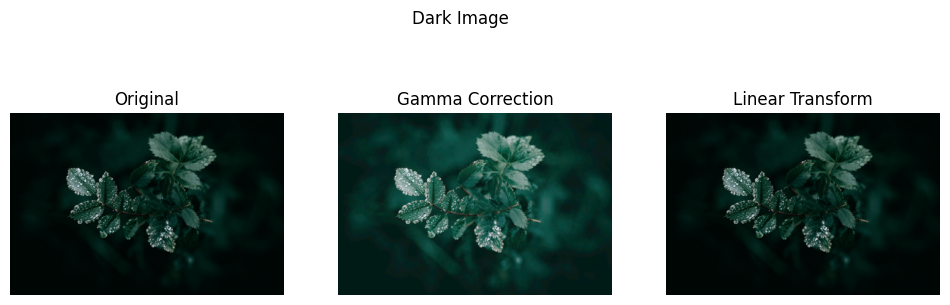

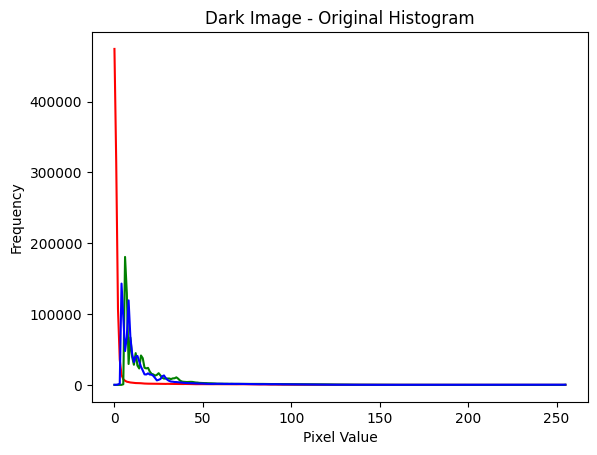

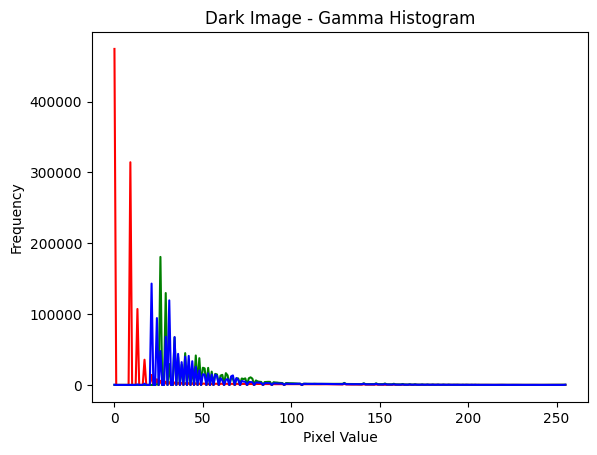

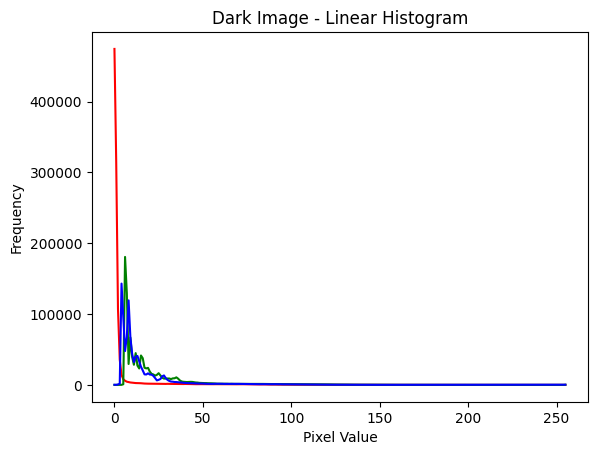

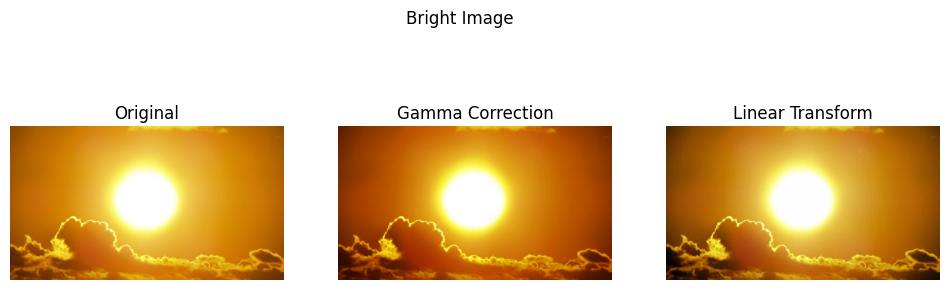

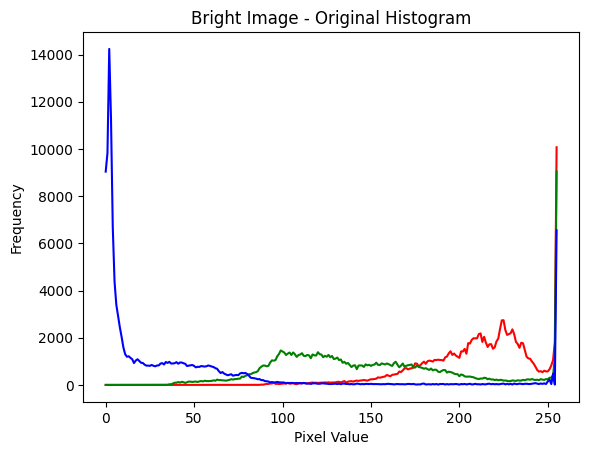

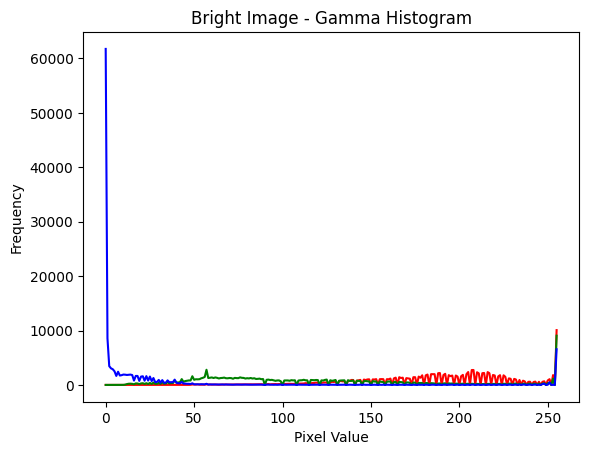

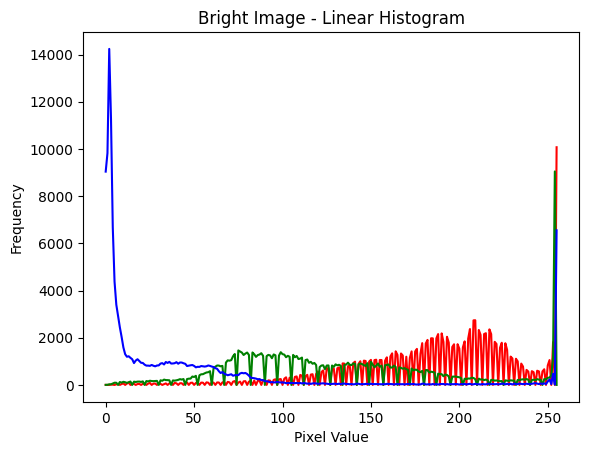

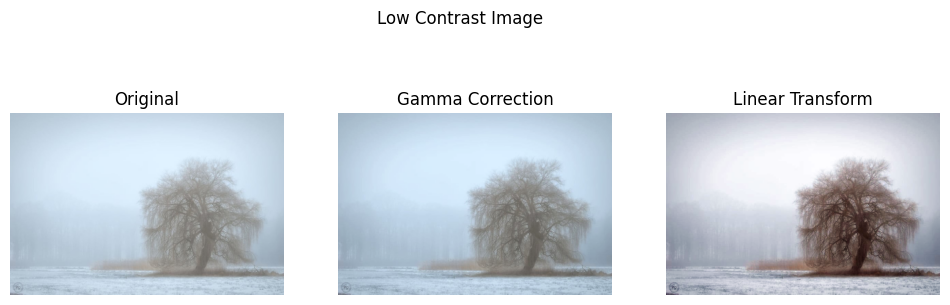

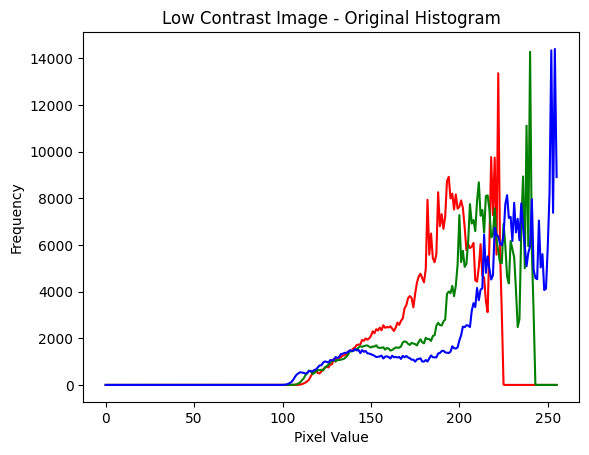

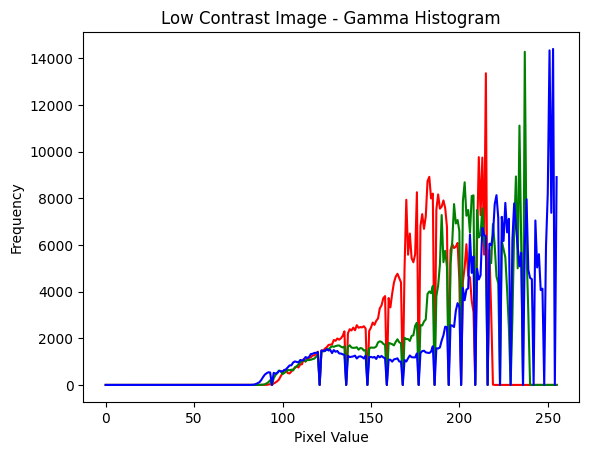

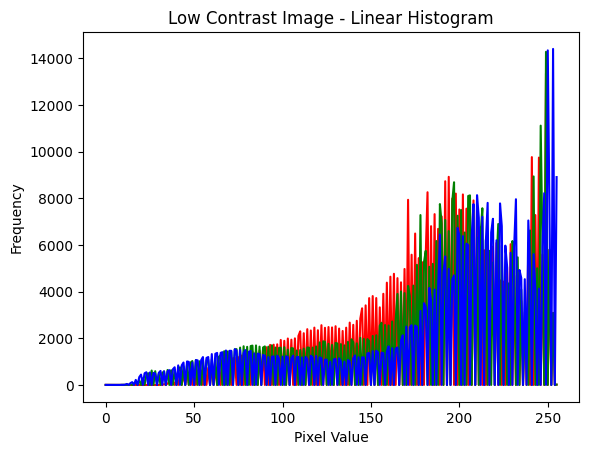

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt


def load_image(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return img


def gamma_correction(image, gamma):
    width, height = image.size
    pixels = image.load()

    new_img = Image.new("RGB", (width, height))
    new_pixels = new_img.load()

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]

            r_new = int(255 * ((r / 255) ** gamma))
            g_new = int(255 * ((g / 255) ** gamma))
            b_new = int(255 * ((b / 255) ** gamma))

            new_pixels[x, y] = (r_new, g_new, b_new)

    return new_img


def find_darkest_pixel(hist):
    for i in range(256):
        if hist[i] > 0:
            return i
    return 0


def find_brightest_pixel(hist):
    for i in range(255, -1, -1):
        if hist[i] > 0:
            return i
    return 255


def linear_transform(image):
    width, height = image.size
    pixels = image.load()

    r_hist = [0] * 256
    g_hist = [0] * 256
    b_hist = [0] * 256

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]
            r_hist[r] += 1
            g_hist[g] += 1
            b_hist[b] += 1

    desired_range = 255

    r_begin = find_darkest_pixel(r_hist)
    r_end = find_brightest_pixel(r_hist)
    g_begin = find_darkest_pixel(g_hist)
    g_end = find_brightest_pixel(g_hist)
    b_begin = find_darkest_pixel(b_hist)
    b_end = find_brightest_pixel(b_hist)

    r_range = r_end - r_begin
    g_range = g_end - g_begin
    b_range = b_end - b_begin

    r_stretch = desired_range / r_range if r_range != 0 else 1
    g_stretch = desired_range / g_range if g_range != 0 else 1
    b_stretch = desired_range / b_range if b_range != 0 else 1

    new_img = Image.new("RGB", (width, height))
    new_pixels = new_img.load()

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]

            r_new = int(r_stretch * (r - r_begin))
            g_new = int(g_stretch * (g - g_begin))
            b_new = int(b_stretch * (b - b_begin))

            r_new = max(0, min(255, r_new))
            g_new = max(0, min(255, g_new))
            b_new = max(0, min(255, b_new))

            new_pixels[x, y] = (r_new, g_new, b_new)

    return new_img


def calculate_histogram(image):
    width, height = image.size
    pixels = image.load()

    r_hist = [0] * 256
    g_hist = [0] * 256
    b_hist = [0] * 256

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]
            r_hist[r] += 1
            g_hist[g] += 1
            b_hist[b] += 1

    return r_hist, g_hist, b_hist


def show_histogram(image, title):
    r_hist, g_hist, b_hist = calculate_histogram(image)

    plt.figure()
    plt.plot(r_hist, color="red")
    plt.plot(g_hist, color="green")
    plt.plot(b_hist, color="blue")

    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()


def show_images(original, gamma_img, linear_img, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gamma_img)
    plt.title("Gamma Correction")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(linear_img)
    plt.title("Linear Transform")
    plt.axis("off")

    plt.suptitle(title)
    plt.show()


dark_image_url = "https://cdn.pixabay.com/photo/2023/10/12/17/56/after-the-rain-8311416_1280.jpg"
bright_image_url = "https://images.pexels.com/photos/301599/pexels-photo-301599.jpeg?auto=compress&cs=tinysrgb&dpr=1&w=500"
low_contrast_url = "https://petapixel.com/assets/uploads/2019/04/p2219651326-5-800x533.jpg"

image_urls = [
    ("Dark Image", dark_image_url, 0.6),
    ("Bright Image", bright_image_url, 1.6),
    ("Low Contrast Image", low_contrast_url, 1.2)
]

for name, url, gamma_value in image_urls:
    img = load_image(url)
    gamma_img = gamma_correction(img, gamma_value)
    linear_img = linear_transform(img)

    show_images(img, gamma_img, linear_img, name)

    show_histogram(img, name + " - Original Histogram")
    show_histogram(gamma_img, name + " - Gamma Histogram")
    show_histogram(linear_img, name + " - Linear Histogram")

# **Secinājumi**

**Kādas galvenās vizuālās atšķirības ir redzamas starp dažādām kontrasta korekcijas metodēm?**

spilgtums gamma korekcija tiek mainīts nelineāri, proti, grafiks parāda haotiskas izmaiņas, savukārt histogrammas lineārā pārveidošana samaina šo spilgtumu lineāri. Attēls pie gamma korekcijas var izskatīties pārāk gaišs vai pārāk tumšs, ja netiek izvēlēta pareiza gamma vērtība, bet histogrammas lineārā pārveidošana pati nosaka šo vērtību, kāda ir nepieciešama.

**Kura metode vislabāk uzlabo attēlu kvalitāti un saglabā detaļas?**

Pareizi izvēlēta gammas vērtība pie gammas korekciju labāk uzlabo attēla kvalitāti/saglabā detaļas, nekā lineārā pārveidošana. Labs piemērs ir pirmā bilde, kas parāda šīs izmaiņas vislabāk. Savukārt pie zema kontrasta bildēm labāk to izdevās uzlabot histogrammas lineārā pārveidošana.

**Kādas ir katras metodes priekšrocības un trūkumi?**

Trūkumi:
* Gamma korekcija:
  * Jānosaka pašam gammas vērtība.
  * Spilgtums netiek lineāri nomainīts, kas var pāris vietām likt izskatīties pārāk spilgtām vai pārāk tumšām.
* Histogrammas lineārā pārveidošana:
  * Var zaudēt attēla detaļas pārāk tumšās vai pārāk gaišās vietās.
  * Pārāk liels kontrasts dažās attēla vietās.

Priekšrocības:
* Gamma korekcija:
  * Labāk uzlabo attēla izskatu pie pareizas gamma vērtības
  * vieglāk implementēt
* Histogrammas lineārā pārveidošana:
  * Nav pašam jānosaka papildus vērtības
  * Labāk strādā pie zema kontrasta bildēm

**Izaicinājumi:**
Praktiski pielietot jaunos jēdzienus, kā histogramma, līdz šim nezināju, kas tas vispār ir.

Grūtākāis efekts, ko realizēju bija Histogrammas lineārā pārveidošana, jo nācās pielietot vairākas formulas un padziļināti strādāt ar masīviem, salīdzinot ar gamma korekciju.

**Ieguvumi:**

Apguvu jaunus jēdzienus kā histogramma un praktiski pielietoju tos. Uzlaboju savas programmēšanas prasmes, kā strādāt masīviem un pielietot matemātiskas formulas kodā.